# EDS Parquet Explorer (Run log + per-run manifest)

This notebook is for visualising Parquet outputs from the optimised EDS pipeline (`eds_master_pipeline_optimised.py`).

Primary target (ongoing record):
- **Run log parquet**: `optimised_eds_runs.parquet` — one row per run (tile, status, requested/effective window, thresholds, etc).

Secondary (per-run detail):
- **Per-run manifest**: `run_manifest.parquet` — the scene list actually used in one run (useful for “what happened on this tile?”).

The Parquet files can live **outside this git repo** (wherever you set `--work-dir`, or in S3).

In [2]:
from __future__ import annotations

from pathlib import Path
from typing import Optional, Union

import pandas as pd

# Plotting (interactive in VS Code notebooks)
import plotly.express as px

ParquetSource = Union[str, Path]

def require_pyarrow() -> None:
    try:
        import pyarrow  # noqa: F401
    except Exception as e:
        raise RuntimeError(
            "pyarrow is required to read parquet. Install it in this kernel, e.g.\n"
            "  %pip install pyarrow\n"
            f"Original error: {e}"
        )

require_pyarrow()

def choose_latest_by_mtime(paths: list[Path]) -> Optional[Path]:
    paths = [Path(p) for p in paths if p is not None]
    if not paths:
        return None
    return max(paths, key=lambda p: p.stat().st_mtime)

def read_parquet_any(source: ParquetSource, columns: Optional[list[str]] = None) -> pd.DataFrame:
    """Read parquet from local path or s3:// URI."""
    if isinstance(source, Path):
        source = str(source)
    source = str(source)
    if source.startswith("s3://"):
        # Requires s3fs + AWS creds in your environment
        try:
            import s3fs  # noqa: F401
        except Exception as e:
            raise RuntimeError(
                "Reading s3:// parquets requires s3fs. Install it in this kernel, e.g.\n"
                "  %pip install s3fs\n"
                f"Original error: {e}"
            )
        return pd.read_parquet(source, columns=columns)
    # local file
    p = Path(source)
    if not p.exists():
        raise FileNotFoundError(str(p))
    try:
        return pd.read_parquet(p, columns=columns)
    except TypeError:
        df = pd.read_parquet(p)
        if columns:
            keep = [c for c in columns if c in df.columns]
            return df[keep].copy()
        return df

def to_yyyymmdd_series(s: pd.Series) -> pd.Series:
    # Accept YYYYMMDD or YYYY-MM-DD-ish strings; return YYYYMMDD.
    out = s.astype(str).str.strip()
    out = out.str.replace("-", "", regex=False)
    return out.str.slice(0, 8)

def find_parquets(work_dir: Path) -> dict[str, list[Path]]:
    work_dir = Path(work_dir)
    if not work_dir.exists():
        raise FileNotFoundError(str(work_dir))

    run_manifests = sorted(work_dir.rglob("run_manifest.parquet"))
    tile_manifests = sorted(work_dir.rglob("*_manifest.parquet"))
    run_logs = sorted(work_dir.rglob("optimised_eds_runs.parquet"))

    # Avoid double-counting run_manifest.parquet in *_manifest.parquet matches
    tile_manifests = [p for p in tile_manifests if p.name != "run_manifest.parquet"]

    return {
        "run_manifest": run_manifests,
        "tile_manifest": tile_manifests,
        "run_log": run_logs,
    }

In [3]:
# --- Configure where your outputs live ---

# Local work-dir you used when running the pipeline (can be outside the repo).
# Example: WORK_DIR = Path(r"D:\\eds_work")
WORK_DIR = Path(r"C:\\path\\to\\your\\eds_work_dir")

# Run log parquet (ongoing record). Set ONE of these:
# - local file path, OR
# - s3://bucket/prefix/runs/optimised_eds_runs.parquet
RUN_LOG_URI: Optional[str] = None  # e.g. r"s3://my-bucket/my-prefix/runs/optimised_eds_runs.parquet"

# Optional: if you want to map tiles, provide a WRS2 tile grid shapefile/geojson.
# It should have either (path,row) columns OR lon/lat bounds columns (lon_min/lon_max/lat_min/lat_max) or geometry.
TILE_GRID_PATH: Optional[str] = None  # e.g. r"C:\\data\\eds_lsat_grid_min_max.shp"

# Optional: if you want to inspect per-run manifests too (scene lists)
MAX_MANIFEST_FILES = 200

WORK_DIR.exists(), WORK_DIR

(False, PosixPath('C:\\\\path\\\\to\\\\your\\\\eds_work_dir'))

In [45]:
from pathlib import Path
from typing import Optional

# Local processing/work directory
LOCAL_ROOT = Path("/home/jovyan/scratch/eds-work-processing")

# S3 bucket + root prefix
BUCKET = "dcceew-eds-data"
S3_ROOT = "eds"

# Run log parquet on S3
RUN_LOG_URI: Optional[str] = (
    f"s3://{BUCKET}/{S3_ROOT}/runs/optimised_eds_runs.parquet"
)

# Optional tile grid
TILE_GRID_PATH: Optional[str] = None
TILE_GRID_PATH =Path("/home/jovyan/work-easi-eds/assets/eds-lsat-tiles.shp")
# Optional manifest inspection count
MAX_MANIFEST_FILES = 200

In [46]:
# parquet_files = find_parquets(WORK_DIR)

# # Choose run log location: explicit URI wins; otherwise pick the newest local cache found under WORK_DIR.
# run_log_candidates = parquet_files.get("run_log", [])
# run_log_uri = RUN_LOG_URI or (str(choose_latest_by_mtime(run_log_candidates)) if run_log_candidates else None)

# {
#     "run_manifest": len(parquet_files.get("run_manifest", [])),
#     "tile_manifest": len(parquet_files.get("tile_manifest", [])),
#     "run_log_candidates": len(run_log_candidates),
#     "run_log_uri": run_log_uri,
# }

In [47]:
run_log_uri = RUN_LOG_URI

{
    "run_manifest": "not checked locally",
    "tile_manifest": "not checked locally",
    "run_log_candidates": 1 if run_log_uri else 0,
    "run_log_uri": run_log_uri,
}

{'run_manifest': 'not checked locally',
 'tile_manifest': 'not checked locally',
 'run_log_candidates': 1,
 'run_log_uri': 's3://dcceew-eds-data/eds/runs/optimised_eds_runs.parquet'}

## Run log (ongoing record)
This is the main dataset for “what has happened across tiles / across Australia”. It is written by the pipeline to S3 by default (`.../runs/optimised_eds_runs.parquet`) and also cached locally under `<work_dir>/<tile>/run_logs/optimised_eds_runs.parquet` when the pipeline runs.

In [48]:
if not run_log_uri:
    print("No run log parquet found. Set RUN_LOG_URI (local path or s3://...) or point WORK_DIR at a folder containing run_logs/optimised_eds_runs.parquet")
    run_log_df = None
else:
    run_log_df = read_parquet_any(run_log_uri)
    print("Loaded run log:", run_log_uri)
    print("rows:", len(run_log_df), "cols:", len(run_log_df.columns))
    run_log_df.head(5)

Loaded run log: s3://dcceew-eds-data/eds/runs/optimised_eds_runs.parquet
rows: 19 cols: 27


In [64]:
from IPython.display import display

if not run_log_uri:
    print(
        "No run log parquet found. "
        "Set RUN_LOG_URI (local path or s3://...) "
        "or point WORK_DIR at a folder containing "
        "run_logs/optimised_eds_runs.parquet"
    )
    run_log_df = None

else:
    run_log_df = read_parquet_any(run_log_uri)

    print("Loaded run log:", run_log_uri)
    print("rows:", len(run_log_df))
    print("cols:", len(run_log_df.columns))

    display(run_log_df.head(5))

Loaded run log: s3://dcceew-eds-data/eds/runs/optimised_eds_runs.parquet
rows: 19
cols: 27


,run_id,pipeline,tile,run_tag,status,started_at_utc,finished_at_utc,requested_start_yyyymmdd,requested_end_yyyymmdd,effective_start_yyyymmdd,...,chunk,strong_threshold,clear_threshold,min_area_ha,dry_run,rebase,run_manifest_uri,s3_bucket,s3_prefix,error_message
0,90006a1b-5d37-4bd4-948e-683190ac7c58,optimised_processing,p115r079,p115r079_d2025112920260201,success,2026-05-14T23:50:42+00:00,2026-05-15T00:02:02+00:00,20251129,20260201,20251129,...,2048,60,80,10.0,False,False,s3://dcceew-eds-data/eds/runs/manifests/p115r0...,dcceew-eds-data,eds,None
1,e8ac1738-3953-46c1-b2d2-665820a95043,optimised_processing,p089r082,p089r082_d2025082620260125,success,2026-05-15T05:01:23+00:00,2026-05-15T05:19:31+00:00,20250826,20260125,20250826,...,2048,60,80,10.0,False,False,s3://dcceew-eds-data/eds/runs/manifests/p089r0...,dcceew-eds-data,eds,None
2,c0951b1e-48af-4efc-be13-584c54935e57,optimised_processing,p089r078,p089r078_d2025070120260117,success,2026-05-18T02:06:08+00:00,2026-05-18T02:20:59+00:00,20250701,20260117,20250701,...,2048,60,80,10.0,False,False,s3://dcceew-eds-data/eds/runs/manifests/p089r0...,dcceew-eds-data,eds,None
3,a689ace2-22e7-4f87-9da2-5d2af7c70468,optimised_processing,p089r078,p089r078_d2025070120260117,success,2026-05-18T03:39:18+00:00,2026-05-18T03:46:59+00:00,20250701,20260117,20250701,...,2048,60,80,10.0,False,False,s3://dcceew-eds-data/eds/runs/manifests/p089r0...,dcceew-eds-data,eds,None
4,3facd9ce-178c-4dfc-ae9a-045112d254ff,optimised_processing,p089r078,p089r078_d2025070120260117,success,2026-05-18T04:43:50+00:00,2026-05-18T04:51:31+00:00,20250701,20260117,20250701,...,2048,60,80,10.0,False,False,s3://dcceew-eds-data/eds/runs/manifests/p089r0...,dcceew-eds-data,eds,None


In [65]:
print("Columns:")
print(run_log_df.columns.tolist())

Columns:
['run_id', 'pipeline', 'tile', 'run_tag', 'status', 'started_at_utc', 'finished_at_utc', 'requested_start_yyyymmdd', 'requested_end_yyyymmdd', 'effective_start_yyyymmdd', 'effective_end_yyyymmdd', 'lookback_years', 'cloud_max', 'ndvi_products', 'sr_products', 'target_epsg', 'resolution', 'chunk', 'strong_threshold', 'clear_threshold', 'min_area_ha', 'dry_run', 'rebase', 'run_manifest_uri', 's3_bucket', 's3_prefix', 'error_message']


In [49]:
if run_log_df is not None:
    r = run_log_df.copy()
    # Normalize timestamps/dates if present
    for c in ("started_at_utc", "finished_at_utc"):
        if c in r.columns:
            r[c] = pd.to_datetime(r[c], errors="coerce")
    if "started_at_utc" in r.columns and "finished_at_utc" in r.columns:
        r["duration_min"] = (r["finished_at_utc"] - r["started_at_utc"]).dt.total_seconds() / 60.0
    # Normalize tiles
    if "tile" in r.columns:
        r["tile"] = r["tile"].astype(str).str.lower().str.strip()
    # Month bucket for charts
    if "started_at_utc" in r.columns:
        r["yyyymm"] = r["started_at_utc"].dt.strftime("%Y%m")
    run_log_clean = r
    print("run_log_clean rows:", len(run_log_clean))
else:
    run_log_clean = None

run_log_clean rows: 19


In [66]:
import pandas as pd
from IPython.display import display

df = run_log_df.copy()

# Convert timestamps
df["started_at_utc"] = pd.to_datetime(df["started_at_utc"], errors="coerce")
df["finished_at_utc"] = pd.to_datetime(df["finished_at_utc"], errors="coerce")

# Convert YYYYMMDD strings to dates
date_cols = [
    "requested_start_yyyymmdd",
    "requested_end_yyyymmdd",
    "effective_start_yyyymmdd",
    "effective_end_yyyymmdd",
]

for col in date_cols:
    df[col] = pd.to_datetime(df[col].astype(str), format="%Y%m%d", errors="coerce")

# Runtime duration
df["runtime_hours"] = (
    (df["finished_at_utc"] - df["started_at_utc"])
    .dt.total_seconds() / 3600
).round(2)

# Select useful columns
view_df = df[
    [
        "tile",
        "run_tag",
        "status",
        "requested_start_yyyymmdd",
        "requested_end_yyyymmdd",
        "effective_start_yyyymmdd",
        "effective_end_yyyymmdd",
        "started_at_utc",
        "finished_at_utc",
        "runtime_hours",
        "cloud_max",
        "target_epsg",
    ]
].sort_values(
    by="started_at_utc",
    ascending=False
)

display(view_df)

,tile,run_tag,status,requested_start_yyyymmdd,requested_end_yyyymmdd,effective_start_yyyymmdd,effective_end_yyyymmdd,started_at_utc,finished_at_utc,runtime_hours,cloud_max,target_epsg
18,p090r085,p090r085_d2025091820260201,success,2025-09-18,2026-02-01,2025-09-18,2026-02-01,2026-05-19 08:24:09+00:00,2026-05-19 08:41:53+00:00,0.30,40.0,0
17,p090r080,p090r080_d2025100420260124,success,2025-10-04,2026-01-24,2025-10-04,2026-01-24,2026-05-19 07:35:36+00:00,2026-05-19 08:03:18+00:00,0.46,40.0,0
16,p090r084,p090r084_d2025110520260201,success,2025-11-05,2026-02-01,2025-11-05,2026-02-01,2026-05-19 07:06:18+00:00,2026-05-19 07:30:50+00:00,0.41,40.0,0
15,p090r083,p090r083_d2025070820260124,success,2025-07-08,2026-01-24,2025-07-08,2026-01-24,2026-05-19 05:49:19+00:00,2026-05-19 06:19:36+00:00,0.50,40.0,0
14,p090r078,p090r078_d2025091020260201,success,2025-09-10,2026-02-01,2025-09-10,2026-02-01,2026-05-19 04:20:32+00:00,2026-05-19 04:49:58+00:00,0.49,40.0,0
13,p090r082,p090r082_d2025110520260124,running,2025-11-05,2026-01-24,2025-11-05,2026-01-24,2026-05-19 04:14:07+00:00,NaT,NaN,40.0,0
12,p090r081,p090r081_d2025110520260124,success,2025-11-05,2026-01-24,2025-11-05,2026-01-24,2026-05-19 02:53:07+00:00,2026-05-19 03:19:14+00:00,0.44,40.0,0
11,p089r084,p089r084_d2025091120260109,success,2025-09-11,2026-01-09,2025-09-11,2026-01-09,2026-05-19 01:06:41+00:00,2026-05-19 01:19:08+00:00,0.21,40.0,0
10,p089r081,p089r081_d2025082620260125,running,2025-08-26,2026-01-25,2025-08-26,2026-01-25,2026-05-19 00:58:35+00:00,NaT,NaN,40.0,0
9,p089r083,p089r083_d2025091120260109,success,2025-09-11,2026-01-09,2025-09-11,2026-01-09,2026-05-19 00:07:41+00:00,2026-05-19 00:22:36+00:00,0.25,40.0,0


In [69]:
# Filter

In [67]:
view_df[view_df["tile"] == "p089r082"]

,tile,run_tag,status,requested_start_yyyymmdd,requested_end_yyyymmdd,effective_start_yyyymmdd,effective_end_yyyymmdd,started_at_utc,finished_at_utc,runtime_hours,cloud_max,target_epsg
7,p089r082,p089r082_d2025082620260125,success,2025-08-26,2026-01-25,2025-08-26,2026-01-25,2026-05-18 23:01:13+00:00,2026-05-18 23:20:06+00:00,0.31,40.0,0
1,p089r082,p089r082_d2025082620260125,success,2025-08-26,2026-01-25,2025-08-26,2026-01-25,2026-05-15 05:01:23+00:00,2026-05-15 05:19:31+00:00,0.30,40.0,0


In [68]:
view_df[view_df["status"] != "success"]

,tile,run_tag,status,requested_start_yyyymmdd,requested_end_yyyymmdd,effective_start_yyyymmdd,effective_end_yyyymmdd,started_at_utc,finished_at_utc,runtime_hours,cloud_max,target_epsg
13,p090r082,p090r082_d2025110520260124,running,2025-11-05,2026-01-24,2025-11-05,2026-01-24,2026-05-19 04:14:07+00:00,NaT,NaN,40.0,0
10,p089r081,p089r081_d2025082620260125,running,2025-08-26,2026-01-25,2025-08-26,2026-01-25,2026-05-19 00:58:35+00:00,NaT,NaN,40.0,0


In [50]:
if run_log_clean is None:
    print("No run log loaded.")
else:
    if "status" in run_log_clean.columns:
        status_counts = run_log_clean["status"].fillna("unknown").value_counts().reset_index()
        status_counts.columns = ["status", "runs"]
        display(status_counts)
        px.bar(status_counts, x="status", y="runs", title="EDS run log: run statuses")
    else:
        print("Run log has no 'status' column. Columns:", list(run_log_clean.columns))

,status,runs
0,success,17
1,running,2


In [51]:
if run_log_clean is None:
    print("No run log loaded.")
else:
    if "started_at_utc" in run_log_clean.columns:
        by_month = run_log_clean.groupby("yyyymm", dropna=False).size().reset_index(name="runs")
        by_month = by_month.sort_values("yyyymm")
        px.bar(by_month, x="yyyymm", y="runs", title="EDS run log: runs per month")
    else:
        print("No started_at_utc column; cannot plot runs per month.")

In [52]:
if run_log_clean is None:
    print("No run log loaded.")
else:
    # Tiles with the most runs
    if "tile" in run_log_clean.columns:
        top_tiles = (run_log_clean["tile"].fillna("unknown").value_counts().head(20).reset_index())
        top_tiles.columns = ["tile", "runs"]
        display(top_tiles)
        px.bar(top_tiles, x="tile", y="runs", title="EDS run log: top tiles by run count")
    else:
        print("No tile column found.")

,tile,runs
0,p089r078,4
1,p089r082,2
2,p115r079,1
3,p089r079,1
4,p089r080,1
5,p089r083,1
6,p089r081,1
7,p089r084,1
8,p090r081,1
9,p090r082,1


In [53]:
# Drill down to a tile
if run_log_clean is None or "tile" not in run_log_clean.columns:
    tile_to_view = None
    print("No run log/tile column available.")
else:
    tiles = [t for t in run_log_clean["tile"].dropna().unique().tolist() if t and t != "unknown"]
    tile_to_view = tiles[0] if tiles else None
tile_to_view

'p115r079'

In [54]:
if run_log_clean is None or tile_to_view is None:
    print("Pick a tile_to_view above.")
else:
    cols_pref = [
        "tile", "run_tag", "status", "started_at_utc", "finished_at_utc", "duration_min",
        "requested_start_yyyymmdd", "requested_end_yyyymmdd",
        "effective_start_yyyymmdd", "effective_end_yyyymmdd",
        "cloud_max", "lookback_years", "min_area_ha", "error_message",
    ]
    cols = [c for c in cols_pref if c in run_log_clean.columns]
    tile_runs = run_log_clean[run_log_clean["tile"] == tile_to_view].copy()
    tile_runs = tile_runs.sort_values("started_at_utc") if "started_at_utc" in tile_runs.columns else tile_runs
    print("runs for tile:", tile_to_view, "=", len(tile_runs))
    display(tile_runs[cols].tail(50) if cols else tile_runs.tail(50))

runs for tile: p115r079 = 1


,tile,run_tag,status,started_at_utc,finished_at_utc,duration_min,requested_start_yyyymmdd,requested_end_yyyymmdd,effective_start_yyyymmdd,effective_end_yyyymmdd,cloud_max,lookback_years,min_area_ha,error_message
0,p115r079,p115r079_d2025112920260201,success,2026-05-14 23:50:42+00:00,2026-05-15 00:02:02+00:00,11.333333,20251129,20260201,20251129,20260201,40.0,10,10.0,None


In [55]:
import geopandas as gpd

gdf = gpd.read_file(TILE_GRID_PATH)

print("CRS:", gdf.crs)
print("Columns:")
print(list(gdf.columns))

display(gdf.head())

CRS: EPSG:4326
Columns:
['AREA', 'PERIMETER', 'PR_', 'PR_ID', 'RINGS_OK', 'RINGS_NOK', 'WRSPR', 'PR', 'PATH', 'ROW', 'MODE', 'DAYCLASS', 'SEQUENCE', 'AOI', 'geometry']


,AREA,PERIMETER,PR_,PR_ID,RINGS_OK,RINGS_NOK,WRSPR,PR,PATH,ROW,MODE,DAYCLASS,SEQUENCE,AOI,geometry
0,2.63261,6.50426,1308,1308,1,0,102068,102068,102,68,D,1,68,0,"POLYGON ((136.64473 -12.31997, 136.37778 -12.2..."
1,2.64625,6.52229,1309,1309,1,0,102069,102069,102,69,D,1,69,0,"POLYGON ((137.28763 -13.63997, 137.27025 -13.7..."
2,2.66238,6.54349,1310,1310,1,0,102070,102070,102,70,D,1,70,0,"POLYGON ((136.37791 -15.26302, 136.35421 -15.2..."
3,2.67962,6.56617,1311,1311,1,0,102071,102071,102,71,D,1,71,0,"POLYGON ((136.93342 -15.26612, 136.934 -15.266..."
4,2.69917,6.59192,1312,1312,1,0,102072,102072,102,72,D,1,72,0,"POLYGON ((136.61557 -16.71084, 136.616 -16.710..."


/tmp/ipykernel_2113/787153746.py:47: UserWarning:

Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.


/tmp/ipykernel_2113/787153746.py:48: UserWarning:

Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.




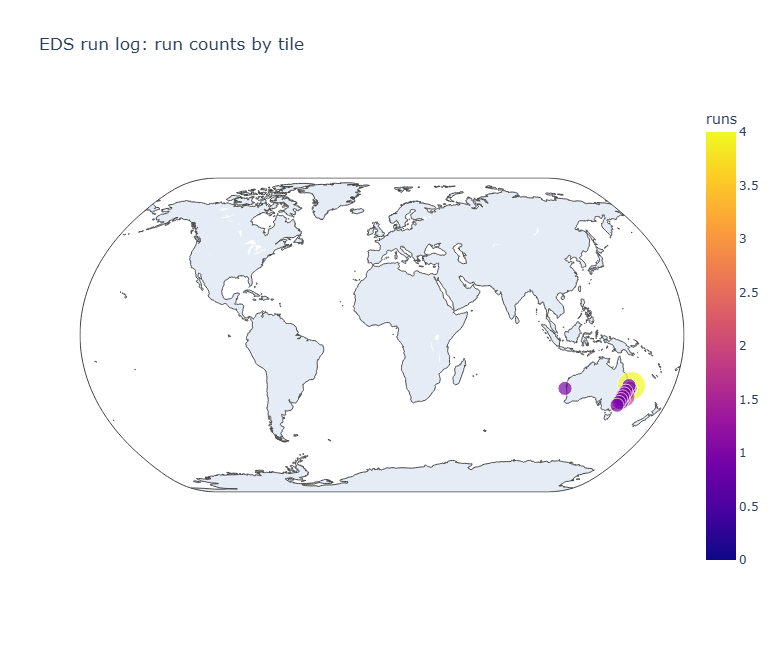

In [56]:
# Optional: map run counts by tile (requires a tile grid file)
if run_log_clean is None or "tile" not in run_log_clean.columns:
    print("No run log loaded.")
elif not TILE_GRID_PATH:
    print("Set TILE_GRID_PATH to a WRS2 tile grid (shp/geojson) to enable mapping.")
else:
    import geopandas as gpd
    import re
    gdf = gpd.read_file(TILE_GRID_PATH)
    # ensure WGS84 for mapping
    if gdf.crs is not None and str(gdf.crs).lower() not in ("epsg:4326", "4326"):
        gdf = gdf.to_crs("EPSG:4326")
    gdf = gdf.copy()
    # derive p###r### tile if possible
    if "tile" not in gdf.columns:
        if "path" in gdf.columns and "row" in gdf.columns:
            gdf["tile"] = gdf.apply(
                lambda r: f"p{int(r['path']):03d}r{int(r['row']):03d}",
                axis=1
            )
    
        elif "PATH" in gdf.columns and "ROW" in gdf.columns:
            gdf["tile"] = gdf.apply(
                lambda r: f"p{int(r['PATH']):03d}r{int(r['ROW']):03d}",
                axis=1
            )
    
        elif "Name" in gdf.columns:
            def _name_to_tile(v: str) -> Optional[str]:
                s = str(v).strip()
                m = re.fullmatch(r"(\d{1,3})_(\d{1,3})", s)
                if not m:
                    return None
                return f"p{int(m.group(1)):03d}r{int(m.group(2)):03d}"
    
            gdf["tile"] = gdf["Name"].apply(_name_to_tile)
    
        else:
            raise RuntimeError(
                f"Cannot derive tile id from TILE_GRID_PATH columns: {list(gdf.columns)}"
            )
    # centroids or bbox midpoints
    if all(c in gdf.columns for c in ("lon_min", "lon_max", "lat_min", "lat_max")):
        gdf["lon"] = (pd.to_numeric(gdf["lon_min"], errors="coerce") + pd.to_numeric(gdf["lon_max"], errors="coerce")) / 2.0
        gdf["lat"] = (pd.to_numeric(gdf["lat_min"], errors="coerce") + pd.to_numeric(gdf["lat_max"], errors="coerce")) / 2.0
    else:
        gdf["lon"] = gdf.geometry.centroid.x
        gdf["lat"] = gdf.geometry.centroid.y
    run_counts = run_log_clean["tile"].value_counts().reset_index()
    run_counts.columns = ["tile", "runs"]
    mdf = gdf.merge(run_counts, on="tile", how="left")
    mdf["runs"] = mdf["runs"].fillna(0).astype(int)
    fig = px.scatter_geo(
        mdf.dropna(subset=["lon", "lat"]),
        lat="lat",
        lon="lon",
        size="runs",
        color="runs",
        hover_name="tile",
        projection="natural earth",
        title="EDS run log: run counts by tile",
    )
    fig.update_layout(height=650)
    fig.show()

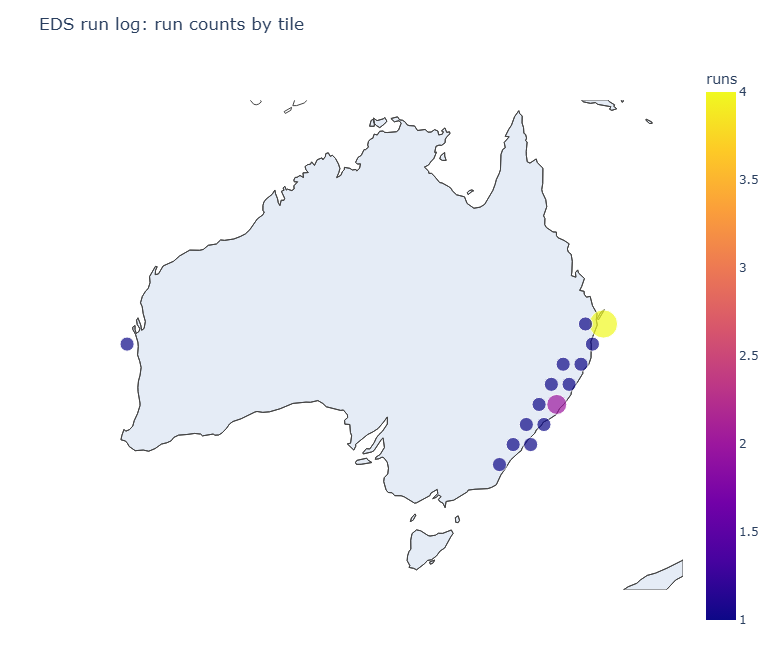

In [57]:
# centroids or bbox midpoints
if all(c in gdf.columns for c in ("lon_min", "lon_max", "lat_min", "lat_max")):
    gdf["lon"] = (
        pd.to_numeric(gdf["lon_min"], errors="coerce") +
        pd.to_numeric(gdf["lon_max"], errors="coerce")
    ) / 2.0
    gdf["lat"] = (
        pd.to_numeric(gdf["lat_min"], errors="coerce") +
        pd.to_numeric(gdf["lat_max"], errors="coerce")
    ) / 2.0
else:
    # Calculate centroid in Australian projected CRS, then convert back to WGS84
    gdf_proj = gdf.to_crs("EPSG:3577")
    centroids = gdf_proj.geometry.centroid
    centroids_wgs84 = gpd.GeoSeries(centroids, crs="EPSG:3577").to_crs("EPSG:4326")

    gdf["lon"] = centroids_wgs84.x
    gdf["lat"] = centroids_wgs84.y

run_counts = run_log_clean["tile"].value_counts().reset_index()
run_counts.columns = ["tile", "runs"]

mdf = gdf.merge(run_counts, on="tile", how="left")
mdf["runs"] = mdf["runs"].fillna(0).astype(int)

# Optional: only show tiles that have at least one run
mdf_plot = mdf[mdf["runs"] > 0].dropna(subset=["lon", "lat"])

fig = px.scatter_geo(
    mdf_plot,
    lat="lat",
    lon="lon",
    size="runs",
    color="runs",
    hover_name="tile",
    hover_data={"runs": True, "lat": False, "lon": False},
    projection="natural earth",
    title="EDS run log: run counts by tile",
    scope="oceania",
)

# Zoom to Australia
fig.update_geos(
    lonaxis_range=[110, 155],
    lataxis_range=[-45, -10],
    showcountries=True,
    showcoastlines=True,
    showland=True,
)

fig.update_layout(
    height=650,
    margin={"r": 20, "t": 60, "l": 20, "b": 20},
)

fig.show()

In [59]:
import s3fs

fs = s3fs.S3FileSystem()

manifest_glob = f"{BUCKET}/{S3_ROOT}/**/*manifest.parquet"

manifest_paths = fs.glob(manifest_glob)[:MAX_MANIFEST_FILES]

print("manifest parquet files:", len(manifest_paths))

manifest_paths[:5]

manifest parquet files: 72


['dcceew-eds-data/eds/manifests/p089r078_manifest.parquet',
 'dcceew-eds-data/eds/manifests/p089r079_manifest.parquet',
 'dcceew-eds-data/eds/manifests/p089r080_manifest.parquet',
 'dcceew-eds-data/eds/manifests/p089r081_manifest.parquet',
 'dcceew-eds-data/eds/manifests/p089r082_manifest.parquet']

In [62]:
manifest_cols = [
    "tile", "date", "platform", "product", "cloud", "target_epsg",
    "lon_min", "lat_min", "lon_max", "lat_max",
    "__filename",
]

manifest_df = pd.concat(
    [
        pd.read_parquet(f"s3://{p}", columns=manifest_cols)
        for p in manifest_paths
    ],
    ignore_index=True,
)

manifest_df.head()

,tile,date,platform,product,cloud,target_epsg,lon_min,lat_min,lon_max,lat_max,__filename
0,p089r078,20250701,L8,ga_ls8c_ard_3,0.015398,32756,152.482,-26.932,154.772,-25.049,dcceew-eds-data/eds/manifests/p089r078_manifes...
1,p089r078,20250802,L8,ga_ls8c_ard_3,36.598298,32756,152.482,-26.932,154.772,-25.049,dcceew-eds-data/eds/manifests/p089r078_manifes...
2,p089r078,20250810,L9,ga_ls9c_ard_3,26.170032,32756,152.482,-26.932,154.772,-25.049,dcceew-eds-data/eds/manifests/p089r078_manifes...
3,p089r078,20250826,L9,ga_ls9c_ard_3,14.112197,32756,152.482,-26.932,154.772,-25.049,dcceew-eds-data/eds/manifests/p089r078_manifes...
4,p089r078,20250903,L8,ga_ls8c_ard_3,16.365710,32756,152.482,-26.932,154.772,-25.049,dcceew-eds-data/eds/manifests/p089r078_manifes...


In [60]:
# --- Optional: per-run manifests (scene lists) ---
manifest_cols = [
    "tile", "date", "platform", "product", "cloud", "target_epsg",
    "lon_min", "lat_min", "lon_max", "lat_max",
    "__source_file__",
 ]

manifest_paths = (parquet_files.get("run_manifest", []) + parquet_files.get("tile_manifest", []))[:MAX_MANIFEST_FILES]
print("manifest parquet files:", len(manifest_paths))
manifest_paths[:5]

NameError: name 'parquet_files' is not defined

In [37]:
if not manifest_paths:
    print("No manifest parquets found under WORK_DIR. (That's fine if you're only using the run log.)")
    manifest_df = None
else:
    manifests: list[pd.DataFrame] = []
    errors: list[tuple[str, str]] = []
    for p in manifest_paths:
        try:
            df = read_parquet_any(p, columns=[c for c in manifest_cols if c != "__source_file__"])
            df["__source_file__"] = str(p)
            manifests.append(df)
        except Exception as e:
            errors.append((str(p), str(e)))
    if errors:
        print(f"[WARN] Failed to read {len(errors)} manifest parquet(s). Showing first 5:")
        for path, msg in errors[:5]:
            print(" -", path)
            print("   ", msg[:200])
    if not manifests:
        print("No manifest parquets could be loaded.")
        manifest_df = None
    else:
        manifest_df = pd.concat(manifests, ignore_index=True)
        manifest_df = manifest_df.copy()
        manifest_df["tile"] = manifest_df.get("tile", "").astype(str).str.lower()
        manifest_df["date"] = to_yyyymmdd_series(manifest_df["date"])
        manifest_df["dt"] = pd.to_datetime(manifest_df["date"], format="%Y%m%d", errors="coerce")
        manifest_df["yyyymm"] = manifest_df["date"].str.slice(0, 6)
        manifest_df["lon_c"] = (pd.to_numeric(manifest_df["lon_min"], errors="coerce") + pd.to_numeric(manifest_df["lon_max"], errors="coerce")) / 2.0
        manifest_df["lat_c"] = (pd.to_numeric(manifest_df["lat_min"], errors="coerce") + pd.to_numeric(manifest_df["lat_max"], errors="coerce")) / 2.0
        print("manifest rows:", len(manifest_df))
        print("manifest tiles:", manifest_df["tile"].nunique())
        manifest_df.head(3)

NameError: name 'manifest_paths' is not defined

## Quick summaries

In [38]:
# Scene counts over time (from manifests)
if manifest_df is None:
    print("No manifest_df loaded; skipping.")
else:
    by_month = manifest_df.groupby("yyyymm", dropna=False).size().reset_index(name="scenes")
    by_month = by_month.sort_values("yyyymm")
    px.bar(by_month, x="yyyymm", y="scenes", title="Scenes per month (from manifest parquet)")

NameError: name 'manifest_df' is not defined

In [39]:
# By product/platform (from manifests)
if manifest_df is None:
    print("No manifest_df loaded; skipping.")
else:
    by_prod = (
        manifest_df.groupby(["product", "platform"], dropna=False).size().reset_index(name="scenes")
        .sort_values("scenes", ascending=False)
    )
    by_prod.head(15)

NameError: name 'manifest_df' is not defined

## Tile view (what happened on one tile?)

In [40]:
# Pick a tile you care about (from manifests)
if manifest_df is None:
    tile_to_view = None
    print("No manifest_df loaded; skipping tile manifest view.")
else:
    tiles = manifest_df["tile"].dropna().astype(str).unique().tolist()
    tile_to_view = tiles[0] if tiles else "p115r078"
tile_to_view

NameError: name 'manifest_df' is not defined

In [41]:
if manifest_df is None or tile_to_view is None:
    tile_df = None
    print("No manifest_df/tile_to_view; skipping.")
else:
    tile_df = manifest_df[manifest_df["tile"] == str(tile_to_view).lower()].copy()
    print("rows for tile:", len(tile_df))
    tile_df.sort_values("dt").head(10)

NameError: name 'manifest_df' is not defined

In [42]:
# Timeline of scenes on this tile (from manifests)
if tile_df is None:
    print("No tile_df; skipping.")
else:
    tile_counts = tile_df.groupby("dt").size().reset_index(name="scenes").sort_values("dt")
    px.line(tile_counts, x="dt", y="scenes", markers=True, title=f"{tile_to_view}: scenes per date")

NameError: name 'tile_df' is not defined

In [43]:
# Cloud cover by date (from manifests)
if tile_df is None:
    print("No tile_df; skipping.")
elif "cloud" in tile_df.columns:
    fig = px.scatter(
        tile_df.sort_values("dt"),
        x="dt",
        y="cloud",
        color="product" if "product" in tile_df.columns else None,
        symbol="platform" if "platform" in tile_df.columns else None,
        hover_data=[c for c in ["tile", "date", "product", "platform", "cloud"] if c in tile_df.columns],
        title=f"{tile_to_view}: cloud cover per scene",
    )
    fig.show()
else:
    print("No cloud column found in this parquet schema.")

NameError: name 'tile_df' is not defined

## Australia view (where/when did scenes occur?)

This uses each scene’s **tile bounding box** fields (`lon_min/lat_min/lon_max/lat_max`) to compute a **tile centre point**, then plots those points on a map.

Tip: if you loaded many manifests, this is effectively “across Australia”.

In [44]:
# Aggregate to tile-month for a lighter map (from manifests)
if manifest_df is None:
    tile_month = None
    print("No manifest_df loaded; skipping Australia manifest map.")
else:
    tile_month = (
        manifest_df.groupby(["tile", "yyyymm"], dropna=False)
        .agg(scenes=("date", "size"), lon=("lon_c", "mean"), lat=("lat_c", "mean"))
        .reset_index()
    )
    tile_month = tile_month.dropna(subset=["lon", "lat"])
    tile_month = tile_month.sort_values(["yyyymm", "scenes"], ascending=[True, False])
    tile_month.head(5)

NameError: name 'manifest_df' is not defined

In [ ]:
# Animated map by month (from manifests; may be slow if you have lots of data)
if tile_month is None:
    print("No tile_month; skipping.")
else:
    fig = px.scatter_geo(
        tile_month,
        lat="lat",
        lon="lon",
        size="scenes",
        color="scenes",
        hover_name="tile",
        hover_data={"yyyymm": True, "scenes": True, "lat": ":.3f", "lon": ":.3f"},
        animation_frame="yyyymm",
        projection="natural earth",
        title="EDS manifest scenes by tile (animation by month)",
    )
    fig.update_layout(height=650)
    fig.show()

## Notes on the run log parquet

- The **default** location is `s3://<bucket>/<prefix>/runs/optimised_eds_runs.parquet`.
- When running locally, the pipeline also keeps a **local cache** under `<work_dir>/<tile>/run_logs/optimised_eds_runs.parquet`.
- This notebook loads the run log near the top; the sections below are kept for backwards-compat with older versions of this notebook.

In [ ]:
# Back-compat: show where the run log came from
run_log_uri

In [ ]:
# Back-compat: preview run log
if run_log_clean is None:
    print("No run log loaded.")
else:
    run_log_clean.head(10)

In [ ]:
# Back-compat: status counts (already shown above, but repeated here)
if run_log_clean is None or "status" not in run_log_clean.columns:
    print("No run log/status column.")
else:
    status_counts = run_log_clean["status"].fillna("unknown").value_counts().reset_index()
    status_counts.columns = ["status", "runs"]
    px.bar(status_counts, x="status", y="runs", title="EDS run log: run statuses")